![Built with AI](https://img.shields.io/badge/Built%20with-AI-blue.svg)

# Laboratorio — Almacenamiento en disco y desempeño de I/O

Este notebook es la parte práctica del laboratorio de acceso a disco. Permite medir y comparar:

- acceso secuencial vs acceso aleatorio
- distintos tamaños de bloque
- resultados empíricos vs estimaciones teóricas

---

## Cómo usar este notebook

En este laboratorio encontrará tres tipos de secciones:

- **Ejecute esta celda:** contiene código listo para usar.
- **Analice:** debe interpretar los resultados obtenidos.
- **Conclusión:** debe redactar una respuesta breve con sus hallazgos.

> **Recomendación:** antes de ejecutar todo, revise la sección de
> **configuración** para ajustar el tamaño del archivo y el número de
> lecturas aleatorias según la capacidad de su equipo.

> **Recursos de apoyo:** las figuras de referencia para este laboratorio
> se encuentran en el `README.md` de la guía:
> - **fig1** — Jerarquía de memoria y latencias de referencia
> - **fig2** — Modelo de costo I/O y sus componentes
> - **fig3** — Comparación visual: acceso secuencial vs aleatorio
>
> Se recomienda tenerlas a mano mientras ejecuta el notebook.

## 0. Verificación del entorno

Ejecute la siguiente celda antes de continuar. Confirmará que todas
las librerías necesarias están disponibles en su entorno.

Si alguna librería aparece marcada con ✗, instálela con:

```bash
pip install nombre_libreria
```

En Google Colab todas las librerías ya están disponibles.

In [4]:
import sys
import importlib

librerias_requeridas = {
    'numpy': 'numpy',
    'pandas': 'pandas',
    'matplotlib': 'matplotlib',
}

print(f'Python: {sys.version}')
print('-' * 40)

todo_ok = True
for nombre, modulo in librerias_requeridas.items():
    try:
        lib = importlib.import_module(modulo)
        version = getattr(lib, '__version__', 'versión no disponible')
        print(f'✓ {nombre} {version}')
    except ImportError:
        print(f'✗ {nombre} — NO encontrada. Instale con: pip install {nombre}')
        todo_ok = False

print('-' * 40)
if todo_ok:
    print('Entorno listo. Puede continuar con el laboratorio.')
else:
    print('Corrija las dependencias faltantes antes de continuar.')

Python: 3.14.3 (tags/v3.14.3:323c59a, Feb  3 2026, 16:04:56) [MSC v.1944 64 bit (AMD64)]
----------------------------------------
✓ numpy 2.4.3
✓ pandas 3.0.1
✓ matplotlib 3.10.8
----------------------------------------
Entorno listo. Puede continuar con el laboratorio.


## 1. Objetivos del notebook

Al finalizar esta práctica debería poder:

1. Entender cómo afecta el patrón de acceso al rendimiento.
2. Medir tiempos de lectura secuencial y aleatoria.
3. Calcular throughput empírico.
4. Comparar mediciones con un modelo teórico simple de I/O.
5. Visualizar los resultados con gráficas automáticas.

In [5]:
import os
import time
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print('Entorno listo.')

Entorno listo.


## 2. Recordatorio teórico

Antes de iniciar las mediciones, repase los conceptos clave que
usará a lo largo del experimento.

### Jerarquía de memoria y costo de acceso

Los dispositivos de almacenamiento tienen latencias muy distintas.
Un acceso a RAM toma nanosegundos; un acceso a disco puede tomar
milisegundos — una diferencia de hasta un millón de veces. Por eso
los sistemas están diseñados para minimizar los accesos a disco.

### Bloques de I/O

El disco no lee bytes individuales — lee **bloques completos**.
Incluso si un programa solicita 1 byte, el sistema transfiere todo
el bloque (típicamente 4 KB en sistemas operativos, 4–16 KB en
motores de bases de datos).

### Patrones de acceso

- **Secuencial:** los bloques se leen uno tras otro en posiciones
  contiguas. El número de accesos físicos al disco es mínimo (M ≈ 1).
- **Aleatorio:** cada bloque está en una posición distinta del disco.
  Cada acceso requiere posicionamiento independiente, por lo que M
  puede ser muy grande.

### Modelo de costo I/O

$$TotalTime = AccessLatency \times M + \frac{DataSize}{ScanThroughput}$$

- **AccessLatency:** tiempo para acceder al inicio de un bloque.
- **M:** número de accesos no contiguos al disco.
- **DataSize:** volumen total de datos a leer.
- **ScanThroughput:** velocidad de lectura sostenida del dispositivo.

> **Conexión con clase:** en las diapositivas se estudió el modelo
> detallado del HDD: $T_{access} = T_{seek} + T_{rotation} + T_{transfer}$.
> En este laboratorio, $AccessLatency$ agrupa $T_{seek}$ y $T_{rotation}$
> en un único valor promedio. Esta simplificación permite comparar
> tecnologías distintas (HDD, SSD, NVMe) con la misma fórmula.

## Punto de control 1 — Revisión conceptual

Antes de continuar, responda brevemente:

1. ¿Qué representa la latencia en este laboratorio?
2. ¿Qué representa el throughput?
3. ¿Por qué en acceso secuencial normalmente se asume que $M \approx 1$?
4. ¿Por qué en acceso aleatorio $M$ tiende a ser mayor?

> **Criterio mínimo:** cada respuesta debe tener al menos una oración
> propia. No copie definiciones — explíquelo con sus palabras.

### Respuestas

- Respuesta 1:Es el tiempo de espera es lo que tarda el sistema desde que tú le pides un dato hasta que el disco empieza a soltar el primer pedacito de información.

- Respuesta 2: Cuanta informacion se esta moviendo por segundo

- Respuesta 3:Porque los datos estan muy unidos lo que ayuda a que no se tenga que ir dando saltos

- Respuesta 4:Porque los datos estan esparcidos en varias partes

## 3. Configuración del experimento

Puede ajustar estos parámetros según el tiempo disponible y la capacidad del entorno.

In [21]:
# ==============================
# CONFIGURACIÓN GENERAL
# ==============================

DATA_DIR = Path('io_lab_data')
DATA_DIR.mkdir(exist_ok=True)

FILE_PATH = DATA_DIR / 'dataset.bin'

# Tamaño del archivo a generar.
# En Colab se recomienda entre 128 y 512 MB.
FILE_SIZE_MB = 256

# Tamaños de bloque a comparar
BLOCK_SIZES = [4 * 1024, 16 * 1024, 64 * 1024, 256 * 1024]

# Número de lecturas aleatorias por tamaño de bloque
RANDOM_READS = 4000

# Semilla para reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print('Archivo:', FILE_PATH)
print('Tamaño objetivo (MB):', FILE_SIZE_MB)
print('Bloques a probar (bytes):', BLOCK_SIZES)
print('Número de lecturas aleatorias:', RANDOM_READS)

Archivo: io_lab_data\dataset.bin
Tamaño objetivo (MB): 256
Bloques a probar (bytes): [4096, 16384, 65536, 262144]
Número de lecturas aleatorias: 4000


## Punto de control 2 — Reflexión sobre la configuración

Observe los parámetros impresos por la celda anterior y responda:

1. **Tamaño del archivo:** ¿Es suficiente para superar la caché RAM de
   su equipo? Compare con los valores de RAM registrados en la Etapa 1
   de la guía.

2. **Tamaño de bloque:** Los tamaños evaluados (4 KB, 16 KB, 64 KB,
   256 KB) corresponden a tamaños típicos de páginas en sistemas
   operativos y motores de bases de datos. ¿Cuál esperaría que tuviera
   mejor rendimiento en acceso aleatorio y por qué?

3. **Entorno de ejecución:** ¿Está ejecutando en local o en Google Colab?
   Recuerde que en Colab los tiempos medidos corresponden al hardware de
   Google, no al suyo.

### Respuestas

- Respuesta 1:NO ni de lejos

- Respuesta 2:Con 256 KB, el disco hace un solo salto y trae un montón de información de una.

- Respuesta 3: Se esta ejecutando en local

### Reinicio del experimento

Si desea cambiar el tamaño del archivo de prueba y repetir el
experimento desde cero, ejecute la siguiente celda antes de continuar.
Esto eliminará el archivo generado anteriormente y forzará su
recreación con los nuevos parámetros.

> **Nota:** en condiciones normales no es necesario ejecutar esta
> celda. Omítala si es la primera vez que corre el notebook.

In [7]:
# ==============================
# REINICIO DEL EXPERIMENTO
# (opcional — solo si cambió FILE_SIZE_MB)
# ==============================

import shutil

RESET = False  # Cambie a True para eliminar el archivo de prueba

if RESET:
    if DATA_DIR.exists():
        shutil.rmtree(DATA_DIR)
        DATA_DIR.mkdir(exist_ok=True)
        print(f'Carpeta {DATA_DIR} eliminada. El archivo se recreará en la siguiente sección.')
    else:
        print('No hay archivos previos que eliminar.')
else:
    print('RESET = False. No se eliminó ningún archivo.')
    print('Cambie RESET = True si desea repetir el experimento con nuevos parámetros.')

RESET = False. No se eliminó ningún archivo.
Cambie RESET = True si desea repetir el experimento con nuevos parámetros.


## 4. Crear el archivo de prueba

Este archivo simula datos almacenados en disco. Solo se crea si todavía
no existe o si su tamaño no coincide con la configuración actual.

In [23]:
def create_test_file(file_path: Path, size_mb: int, chunk_mb: int = 8) -> None:
    """Crea un archivo binario grande para pruebas de I/O.

    Parámetros:
        file_path: ruta del archivo a crear.
        size_mb: tamaño total del archivo en MB.
        chunk_mb: tamaño del bloque con el que se escribe el archivo.
    """
    target_size = size_mb * 1024 * 1024
    if file_path.exists() and file_path.stat().st_size == target_size:
        print('El archivo ya existe y tiene el tamaño esperado.')
        return

    print(f'Creando archivo de {size_mb} MB...')
    chunk_bytes = chunk_mb * 1024 * 1024
    remaining = target_size

    with open(file_path, 'wb') as f:
        while remaining > 0:
            current = min(chunk_bytes, remaining)
            f.write(os.urandom(current))
            remaining -= current

    print('Archivo creado correctamente.')


create_test_file(FILE_PATH, FILE_SIZE_MB)
print('Tamaño final del archivo (bytes):', FILE_PATH.stat().st_size)

El archivo ya existe y tiene el tamaño esperado.
Tamaño final del archivo (bytes): 268435456


## Analice

Después de crear el archivo, responda:

1. ¿Qué papel cumple este archivo dentro del experimento?
2. ¿Por qué es útil trabajar con un archivo relativamente grande?
3. ¿Qué cree que ocurriría si el archivo fuera demasiado pequeño?

> **Criterio mínimo:** la respuesta 3 debe mencionar explícitamente
> el concepto de caché del sistema operativo.

### Respuestas

- Respuesta 1:Es por decirlo de alguna forma el sujeto de pruebas sobre el cual realizaremos las lecturas

- Respuesta 2:Para volver mas real la simulacion con datos mas estables

- Respuesta 3:Porque quedaria registrado en la cache del dispositivo entonces los tiempos de respuesta cambiarian

## 5. Funciones auxiliares de medición

In [25]:
def format_bytes(num_bytes: int) -> str:
    """Convierte un tamaño en bytes a una representación legible."""
    units = ['B', 'KB', 'MB', 'GB', 'TB']
    value = float(num_bytes)
    for unit in units:
        if value < 1024 or unit == units[-1]:
            return f'{value:.2f} {unit}'
        value /= 1024


def throughput_mib_s(total_bytes: int, elapsed_seconds: float) -> float:
    """Calcula throughput en MiB/s."""
    if elapsed_seconds <= 0:
        return float('inf')
    return (total_bytes / (1024 * 1024)) / elapsed_seconds


def sequential_read_measure(file_path: Path, block_size: int) -> dict:
    """Mide lectura secuencial del archivo completo."""
    total_bytes = 0
    start = time.perf_counter()
    with open(file_path, 'rb', buffering=0) as f:
        while True:
            chunk = f.read(block_size)
            if not chunk:
                break
            total_bytes += len(chunk)
    elapsed = time.perf_counter() - start
    return {
        'pattern': 'Secuencial',
        'block_size_bytes': block_size,
        'total_bytes': total_bytes,
        'operations': math.ceil(total_bytes / block_size),
        'elapsed_s': elapsed,
        'throughput_mib_s': throughput_mib_s(total_bytes, elapsed),
    }


def random_read_measure(file_path: Path, block_size: int, reads: int) -> dict:
    """Mide lectura aleatoria de bloques en posiciones dispersas."""
    file_size = file_path.stat().st_size
    max_offset = file_size - block_size
    if max_offset <= 0:
        raise ValueError('El archivo es más pequeño que el tamaño de bloque.')

    offsets = np.random.randint(0, max_offset + 1, size=reads)
    total_bytes = 0

    start = time.perf_counter()
    with open(file_path, 'rb', buffering=0) as f:
        for offset in offsets:
            f.seek(int(offset))
            chunk = f.read(block_size)
            total_bytes += len(chunk)
    elapsed = time.perf_counter() - start
    return {
        'pattern': 'Aleatorio',
        'block_size_bytes': block_size,
        'total_bytes': total_bytes,
        'operations': reads,
        'elapsed_s': elapsed,
        'throughput_mib_s': throughput_mib_s(total_bytes, elapsed),
    }

## 6. Ejecutar experimentos empíricos

Se ejecutará la medición para cada tamaño de bloque, comparando acceso
secuencial y aleatorio.

In [26]:
results = []

for block_size in BLOCK_SIZES:
    print(f'\nProbando bloque = {format_bytes(block_size)}')

    seq_result = sequential_read_measure(FILE_PATH, block_size)
    rnd_result = random_read_measure(FILE_PATH, block_size, RANDOM_READS)

    results.append(seq_result)
    results.append(rnd_result)

    print(f"Secuencial -> tiempo: {seq_result['elapsed_s']:.4f} s, throughput: {seq_result['throughput_mib_s']:.2f} MiB/s")
    print(f"Aleatorio  -> tiempo: {rnd_result['elapsed_s']:.4f} s, throughput: {rnd_result['throughput_mib_s']:.2f} MiB/s")

df_empirical = pd.DataFrame(results)
df_empirical['block_size_kib'] = df_empirical['block_size_bytes'] / 1024
df_empirical


Probando bloque = 4.00 KB
Secuencial -> tiempo: 0.1922 s, throughput: 1332.03 MiB/s
Aleatorio  -> tiempo: 0.0243 s, throughput: 643.08 MiB/s

Probando bloque = 16.00 KB
Secuencial -> tiempo: 0.0841 s, throughput: 3044.06 MiB/s
Aleatorio  -> tiempo: 0.0430 s, throughput: 1453.28 MiB/s

Probando bloque = 64.00 KB
Secuencial -> tiempo: 0.0497 s, throughput: 5146.59 MiB/s
Aleatorio  -> tiempo: 0.0633 s, throughput: 3949.98 MiB/s

Probando bloque = 256.00 KB
Secuencial -> tiempo: 0.0436 s, throughput: 5867.12 MiB/s
Aleatorio  -> tiempo: 0.1867 s, throughput: 5356.90 MiB/s


,pattern,block_size_bytes,total_bytes,operations,elapsed_s,throughput_mib_s,block_size_kib
0,Secuencial,4096,268435456,65536,0.192188,1332.027670,4.0
1,Aleatorio,4096,16384000,4000,0.024297,643.080861,4.0
2,Secuencial,16384,268435456,16384,0.084098,3044.064017,16.0
3,Aleatorio,16384,65536000,4000,0.043006,1453.282209,16.0
4,Secuencial,65536,268435456,4096,0.049742,5146.587264,64.0
5,Aleatorio,65536,262144000,4000,0.063291,3949.983728,64.0
6,Secuencial,262144,268435456,1024,0.043633,5867.118925,256.0
7,Aleatorio,262144,1048576000,4000,0.186675,5356.897970,256.0


## Análisis de resultados empíricos

Observe la tabla generada y responda:

1. ¿Cuál patrón de acceso fue más rápido para cada tamaño de bloque?
2. ¿El throughput cambió al aumentar el tamaño de bloque?
3. ¿En qué caso observó la mayor diferencia entre secuencial y aleatorio?

> **Criterio mínimo:** la respuesta 3 debe incluir valores numéricos
> concretos obtenidos de la tabla (throughput en MiB/s o tiempo en s).

### Respuesta

El patron secuencial fue el mas rapido en todos los casos.

El throughput si aumento drasticamente Para el acceso Secuencial, pasamos de 1,332.02 MiB/s (bloque de 4 KB) a 5,867.11 MiB/s (bloque de 256 KB).
Para el acceso Aleatorio, el salto fue aún más notorio: de apenas 643.08 MiB/s a 5,356.89 MiB/s.

La mayor diferencia se observó en el tamaño de bloque más pequeño (4.0 KiB).

Secuencial: 1,332.027670 MiB/s
Aleatorio: 643.080861 MiB/s
Diferencia: El acceso secuencial fue más del doble de rápido (aprox. 2.07x) que el aleatorio.

## 7. Modelo teórico de costo I/O

En esta sección se calculan los tiempos esperados según el modelo
simplificado visto en clase. Estos valores servirán como referencia
para comparar con sus mediciones empíricas.

### Parámetros del dispositivo teórico

Los parámetros a continuación representan un dispositivo de referencia.
Puede ajustarlos para modelar el comportamiento esperado de su equipo:

| Dispositivo | AccessLatency | ScanThroughput |
|---|---|---|
| SSD NVMe (defecto) | 10 µs | 5 GB/s |
| SSD SATA | 100 µs | 500 MB/s |
| HDD | 10 ms | 100 MB/s |

> **Nota:** el parámetro `AccessLatency` de este modelo corresponde
> a la suma de $T_{seek} + T_{rotation}$ del modelo de HDD visto en
> clase. Para un SSD no existe seek ni rotación, pero sí existe una
> latencia del controlador que cumple el mismo rol en la fórmula.
> Ajuste el dispositivo modelado según la tecnología registrada en
> su tabla de caracterización de la Etapa 1.

In [11]:
# ==============================
# PARÁMETROS TEÓRICOS
# ==============================

THEORY_DEVICE = {
    'name': 'SSD aproximado',
    'access_latency_s': 10e-6,
    'scan_throughput_bytes_s': 5 * (1024**3),
}

# Si quiere modelar un HDD, puede descomentar esto:
# THEORY_DEVICE = {
#     'name': 'HDD aproximado',
#     'access_latency_s': 10e-3,
#     'scan_throughput_bytes_s': 100 * (1024**2),
# }

print(THEORY_DEVICE)

{'name': 'SSD aproximado', 'access_latency_s': 1e-05, 'scan_throughput_bytes_s': 5368709120}


## Punto de control 3 — Modelo teórico elegido

Indique cuál dispositivo teórico usó para comparar sus resultados:

- Dispositivo modelado:
- Latencia asumida:
- Throughput asumido:

Luego explique por qué ese modelo podría parecerse o no a su entorno real.

In [12]:
def theoretical_io_time(
    data_size_bytes: int,
    m_accesses: int,
    access_latency_s: float,
    scan_throughput_bytes_s: float
) -> float:
    """Aplica el modelo simplificado de costo I/O."""
    return access_latency_s * m_accesses + (data_size_bytes / scan_throughput_bytes_s)


theory_rows = []
file_size = FILE_PATH.stat().st_size

for block_size in BLOCK_SIZES:
    seq_data_size = file_size
    seq_m = 1
    seq_time = theoretical_io_time(
        data_size_bytes=seq_data_size,
        m_accesses=seq_m,
        access_latency_s=THEORY_DEVICE['access_latency_s'],
        scan_throughput_bytes_s=THEORY_DEVICE['scan_throughput_bytes_s'],
    )

    theory_rows.append({
        'pattern': 'Secuencial',
        'block_size_bytes': block_size,
        'block_size_kib': block_size / 1024,
        'theoretical_elapsed_s': seq_time,
        'theoretical_throughput_mib_s': throughput_mib_s(seq_data_size, seq_time),
    })

    rnd_data_size = block_size * RANDOM_READS
    rnd_m = RANDOM_READS
    rnd_time = theoretical_io_time(
        data_size_bytes=rnd_data_size,
        m_accesses=rnd_m,
        access_latency_s=THEORY_DEVICE['access_latency_s'],
        scan_throughput_bytes_s=THEORY_DEVICE['scan_throughput_bytes_s'],
    )

    theory_rows.append({
        'pattern': 'Aleatorio',
        'block_size_bytes': block_size,
        'block_size_kib': block_size / 1024,
        'theoretical_elapsed_s': rnd_time,
        'theoretical_throughput_mib_s': throughput_mib_s(rnd_data_size, rnd_time),
    })

df_theory = pd.DataFrame(theory_rows)
df_theory

,pattern,block_size_bytes,block_size_kib,theoretical_elapsed_s,theoretical_throughput_mib_s
0,Secuencial,4096,4.0,0.050010,5118.976205
1,Aleatorio,4096,4.0,0.043052,362.935239
2,Secuencial,16384,16.0,0.050010,5118.976205
3,Aleatorio,16384,16.0,0.052207,1197.156753
4,Secuencial,65536,64.0,0.050010,5118.976205
5,Aleatorio,65536,64.0,0.088828,2814.423923
6,Secuencial,262144,256.0,0.050010,5118.976205
7,Aleatorio,262144,256.0,0.235313,4249.667995


## 8. Comparación entre resultados empíricos y teóricos

In [13]:
df_compare = df_empirical.merge(
    df_theory,
    on=['pattern', 'block_size_bytes', 'block_size_kib'],
    how='left'
)

df_compare['elapsed_ratio_empirical_vs_theoretical'] = (
    df_compare['elapsed_s'] / df_compare['theoretical_elapsed_s']
)

df_compare['throughput_ratio_empirical_vs_theoretical'] = (
    df_compare['throughput_mib_s'] / df_compare['theoretical_throughput_mib_s']
)

df_compare

,pattern,block_size_bytes,total_bytes,operations,elapsed_s,throughput_mib_s,block_size_kib,theoretical_elapsed_s,theoretical_throughput_mib_s,elapsed_ratio_empirical_vs_theoretical,throughput_ratio_empirical_vs_theoretical
0,Secuencial,4096,268435456,65536,0.290983,879.777389,4.0,0.050010,5118.976205,5.818490,0.171866
1,Aleatorio,4096,16384000,4000,0.105248,148.459442,4.0,0.043052,362.935239,2.444676,0.409052
2,Secuencial,16384,268435456,16384,0.988816,258.895592,16.0,0.050010,5118.976205,19.772358,0.050576
3,Aleatorio,16384,65536000,4000,0.109884,568.784212,16.0,0.052207,1197.156753,2.104764,0.475113
4,Secuencial,65536,268435456,4096,0.051562,4964.848489,64.0,0.050010,5118.976205,1.031044,0.969891
5,Aleatorio,65536,262144000,4000,0.063799,3918.544426,64.0,0.088828,2814.423923,0.718232,1.392308
6,Secuencial,262144,268435456,1024,0.044902,5701.330475,256.0,0.050010,5118.976205,0.897856,1.113764
7,Aleatorio,262144,1048576000,4000,0.187126,5343.978543,256.0,0.235313,4249.667995,0.795225,1.257505


## Análisis comparativo: teoría vs práctica

Interprete la tabla comparativa:

1. ¿Los tiempos empíricos son mayores o menores que los teóricos?
2. ¿En cuál patrón de acceso la teoría se aproxima mejor?
3. ¿Qué factores reales podrían explicar las diferencias?

> **Criterio mínimo:** la respuesta 3 debe mencionar al menos dos
> factores concretos (por ejemplo: caché del SO, temperatura,
> carga del sistema, tipo de disco).

### Respuesta

En la mayoria de los casos lso tiempos empiricos son mayores que los teoricos especialmente con bloques pequeños

La teoría se aproxima mejor en el acceso secuencial con bloques grandes

Caché del Sistema Operativo: Windows no lee directamente del SSD cada vez que se lo pides. Si el archivo es pequeño, el SO guarda los datos en una sala de espera súper rápida. Esto explica por qué en los bloques grandes el rendimiento real terminó siendo incluso mejor que el teórico

Carga del Sistema: A diferencia del modelo teórico, que asume que el procesador solo está haciendo una cosa, y debido a que se estaba ejecutando Windows 11, el navegador, el notebook y procesos en segundo plano. Estas pequeñas distracciones causan retrasos (latencia) que hacen que el tiempo real sea mayor, especialmente en esos picos donde el ratio subió a 19.

## 9. Gráficas automáticas

Las siguientes gráficas se generan a partir de los resultados del
experimento y se guardan automáticamente en la carpeta `images/`
para que pueda incluirlas en su informe.

In [14]:
# ==============================
# CONFIGURACIÓN DE EXPORTACIÓN
# ==============================

IMAGES_DIR = Path('images')
IMAGES_DIR.mkdir(exist_ok=True)

print(f'Las gráficas se guardarán en: {IMAGES_DIR.resolve()}')

Las gráficas se guardarán en: C:\Users\PC\Desktop\SEMESTRE 2026-1\ESTRUCTURA DE DATOS\labs-repos\lab3-IO_performance-JuanRamirez\images


Guardada: fig_throughput.png


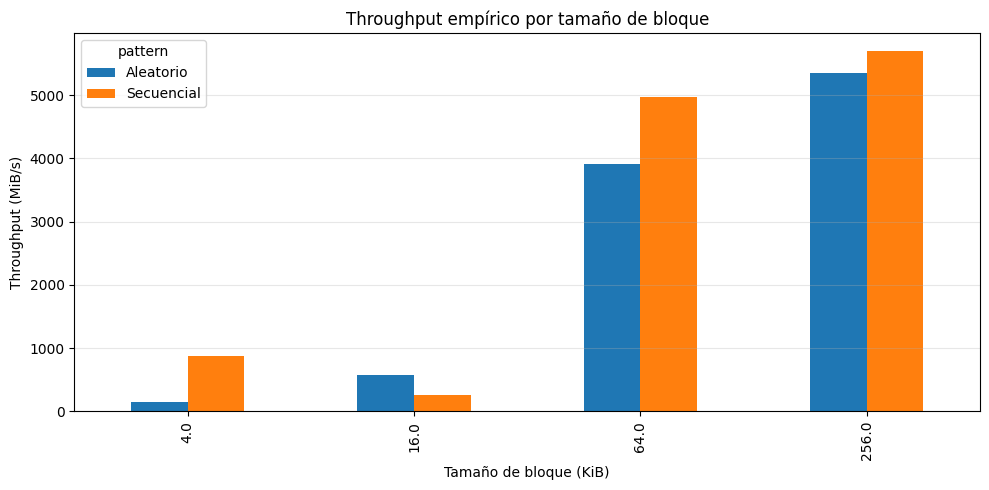

In [15]:
def plot_empirical_throughput(df: pd.DataFrame) -> None:
    """Grafica throughput empírico para secuencial y aleatorio."""
    pivot = df.pivot(
        index='block_size_kib',
        columns='pattern',
        values='throughput_mib_s'
    ).sort_index()
    ax = pivot.plot(kind='bar', figsize=(10, 5))
    ax.set_title('Throughput empírico por tamaño de bloque')
    ax.set_xlabel('Tamaño de bloque (KiB)')
    ax.set_ylabel('Throughput (MiB/s)')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / 'fig_throughput.png', dpi=150, bbox_inches='tight')
    print('Guardada: fig_throughput.png')
    plt.show()


plot_empirical_throughput(df_empirical)

## Interprete la gráfica de throughput

Describa con sus palabras qué muestra esta gráfica:

- ¿Qué barras son más altas?
- ¿Qué significa eso en términos de rendimiento?
- ¿Cuál patrón aprovecha mejor la lectura en bloques?

> **Criterio mínimo:** mencione al menos un tamaño de bloque específico
> y su valor de throughput observado.

### Respuesta

en casi todos los casos las barras mas altas son las de secuencial osea las naranjas excepto en 16KiB

Significa que es mucho más eficiente moviendo archivos cuando los datos están organizados y son grandes.

El patrón Aleatorio es el que más se beneficia de aumentar el tamaño de bloque porque en el bloque de 4.0 KiB, el throughput aleatorio es de apenas 643.08 MiB/s. Pero cuando subimos al bloque de 256.0 KiB, el rendimiento salta a unos increíbles 5,356.90 MiB/s.

Guardada: fig_tiempo_empirico.png


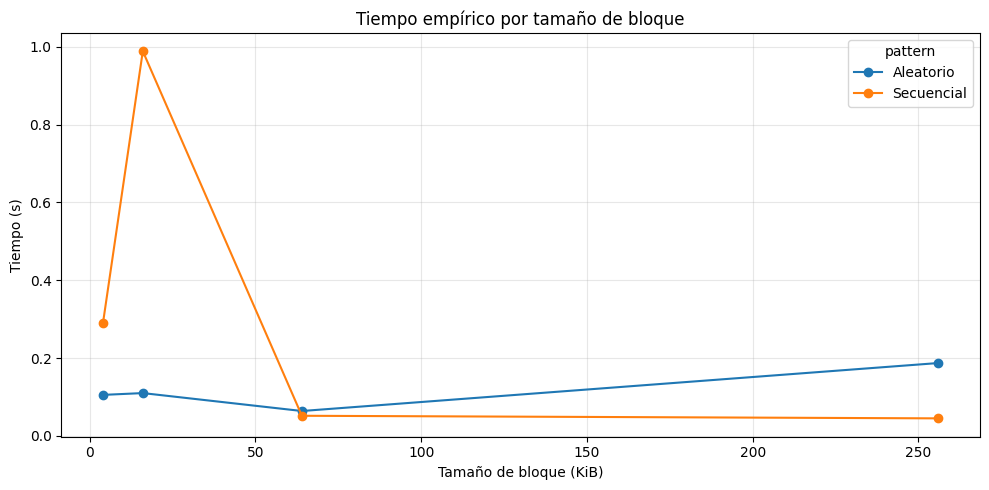

In [16]:
def plot_empirical_time(df: pd.DataFrame) -> None:
    """Grafica tiempo empírico por patrón de acceso."""
    pivot = df.pivot(
        index='block_size_kib',
        columns='pattern',
        values='elapsed_s'
    ).sort_index()
    ax = pivot.plot(marker='o', figsize=(10, 5))
    ax.set_title('Tiempo empírico por tamaño de bloque')
    ax.set_xlabel('Tamaño de bloque (KiB)')
    ax.set_ylabel('Tiempo (s)')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / 'fig_tiempo_empirico.png', dpi=150, bbox_inches='tight')
    print('Guardada: fig_tiempo_empirico.png')
    plt.show()


plot_empirical_time(df_empirical)

## Interprete la gráfica de tiempo

Explique cómo cambia el tiempo total cuando cambia el tamaño de bloque.

> **Criterio mínimo:** compare el comportamiento de la curva secuencial
> con la aleatorio e indique en qué punto divergen más.

### Respuesta
Curva Secuencial (Naranja): Esta curva es la más rara de los resultados ya que empieza con un tiempo de 0.1922 s para bloques de 4 KB, pero luego tiene un salto extraño a casi 1 segundo (0.9888 s) en los 16 KB, para luego caer en picada y volverse súper eficiente en los 256 KB (0.0436 s). Esto indica que a tu sistema le costó procesar los bloques medianos, pero voló con los grandes.

Curva Aleatoria (Azul): Es mucho más estable y lógica ya que empieza muy bajito (0.0243 s) porque en el bloque de 4 KB se le pidió leer menos datos totales en la prueba aleatoria, pero sube de forma constante hasta los 0.1867 s en los 256 KB.


Guardada: fig_tiempo_teoria_vs_practica_secuencial.png


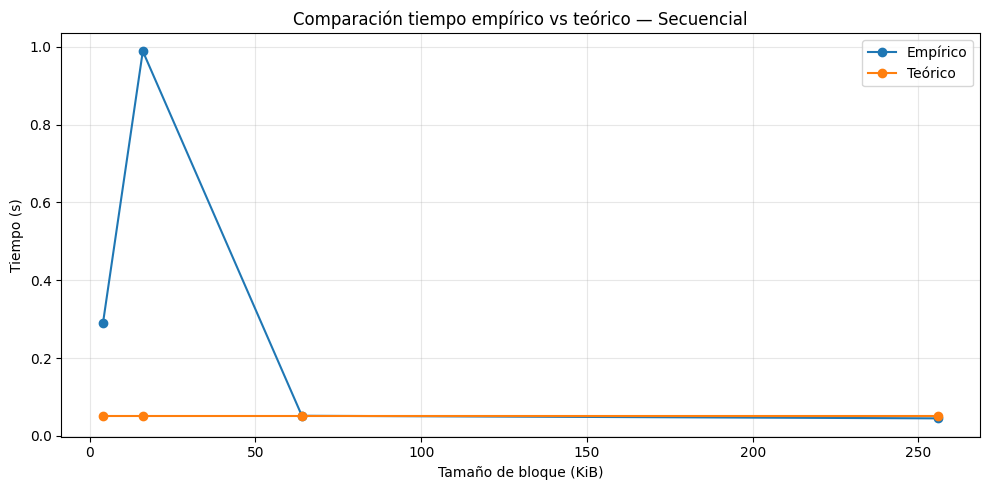

Guardada: fig_tiempo_teoria_vs_practica_aleatorio.png


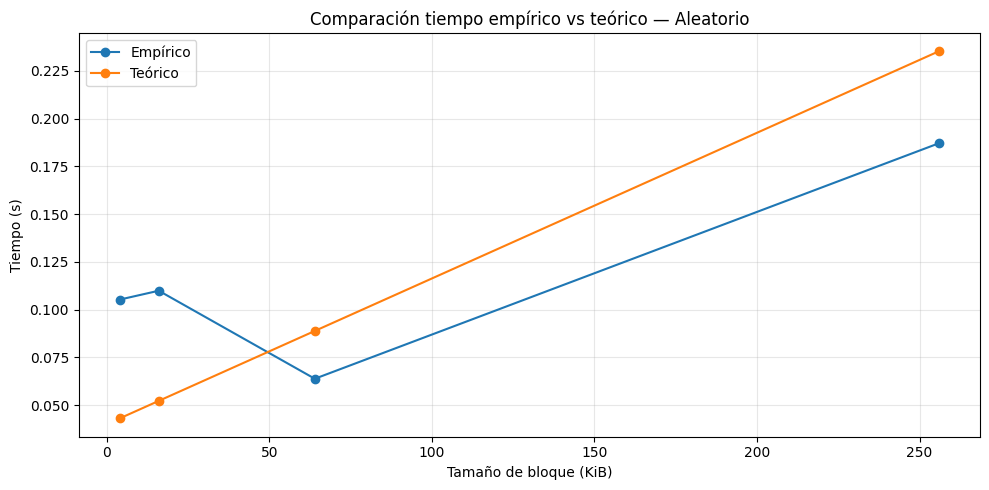

In [17]:
def plot_theory_vs_empirical(df: pd.DataFrame, pattern: str) -> None:
    """Compara tiempo empírico y teórico para un patrón dado."""
    subset = df[df['pattern'] == pattern].sort_values('block_size_kib')
    plt.figure(figsize=(10, 5))
    plt.plot(subset['block_size_kib'], subset['elapsed_s'],
             marker='o', label='Empírico')
    plt.plot(subset['block_size_kib'], subset['theoretical_elapsed_s'],
             marker='o', label='Teórico')
    plt.title(f'Comparación tiempo empírico vs teórico — {pattern}')
    plt.xlabel('Tamaño de bloque (KiB)')
    plt.ylabel('Tiempo (s)')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    nombre = f'fig_tiempo_teoria_vs_practica_{pattern.lower()}.png'
    plt.savefig(IMAGES_DIR / nombre, dpi=150, bbox_inches='tight')
    print(f'Guardada: {nombre}')
    plt.show()


plot_theory_vs_empirical(df_compare, 'Secuencial')
plot_theory_vs_empirical(df_compare, 'Aleatorio')

## Interprete la comparación empírico vs teórico

Observe las curvas y responda:

1. ¿Las curvas tienen una tendencia similar?
2. ¿Dónde se separan más?
3. ¿Qué le sugiere eso sobre el modelo usado?

> **Criterio mínimo:** la respuesta 3 debe indicar si el modelo
> sobreestima o subestima el tiempo real, y proponer una razón.

### Respuesta

1.Solo de forma parcial y en los extremos.

2.Se separan más en los bloques pequeños y en el punto crítico de los 64 KiB.

3.El modelo es demasiado optimista (sobreestima la velocidad real) en bloques pequeños y demasiado pesimista (subestima el poder de la caché) en bloques grandes.


Guardada: fig_speedup.png


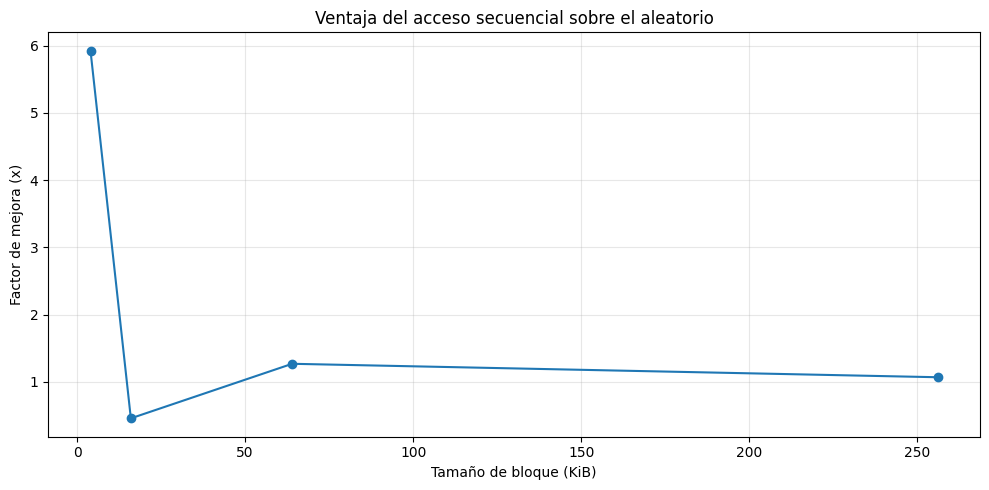

In [18]:
def plot_sequential_speedup(df: pd.DataFrame) -> None:
    """Grafica cuántas veces el acceso secuencial supera al aleatorio."""
    pivot = df.pivot(
        index='block_size_kib',
        columns='pattern',
        values='throughput_mib_s'
    ).sort_index()
    speedup = pivot['Secuencial'] / pivot['Aleatorio']
    ax = speedup.plot(marker='o', figsize=(10, 5))
    ax.set_title('Ventaja del acceso secuencial sobre el aleatorio')
    ax.set_xlabel('Tamaño de bloque (KiB)')
    ax.set_ylabel('Factor de mejora (x)')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / 'fig_speedup.png', dpi=150, bbox_inches='tight')
    print('Guardada: fig_speedup.png')
    plt.show()


plot_sequential_speedup(df_empirical)

## Interprete la ventaja del acceso secuencial

La gráfica muestra cuántas veces el acceso secuencial supera al aleatorio.

- ¿Cuál fue el mayor factor de mejora observado?
- ¿Cómo cambia esa ventaja con el tamaño de bloque?
- ¿Qué implicación tiene esto para el diseño de software?

> **Criterio mínimo:** incluya el valor numérico del mayor speedup
> observado y el tamaño de bloque en que ocurrió.

### Respuesta

El mayor factor de mejora (o speedup) fue de 5.92x (casi 6 veces más rápido).

La ventaja cae en picada a medida que el bloque se hace más grande.

Si los datos son pequeños hay que mantenerlos ordenados y si no se puede mantener el orden hay que leer bloques mas grandes

## 10. Resumen automático de resultados

In [19]:
summary_rows = []
for block_size in sorted(df_empirical['block_size_bytes'].unique()):
    seq = df_empirical[
        (df_empirical['block_size_bytes'] == block_size) &
        (df_empirical['pattern'] == 'Secuencial')
    ].iloc[0]
    rnd = df_empirical[
        (df_empirical['block_size_bytes'] == block_size) &
        (df_empirical['pattern'] == 'Aleatorio')
    ].iloc[0]
    summary_rows.append({
        'block_size_kib': block_size / 1024,
        'seq_time_s': seq['elapsed_s'],
        'rnd_time_s': rnd['elapsed_s'],
        'seq_throughput_mib_s': seq['throughput_mib_s'],
        'rnd_throughput_mib_s': rnd['throughput_mib_s'],
        'seq_vs_rnd_speedup': (
            seq['throughput_mib_s'] / rnd['throughput_mib_s']
            if rnd['throughput_mib_s'] > 0 else np.nan
        ),
    })

df_summary = pd.DataFrame(summary_rows)
df_summary

,block_size_kib,seq_time_s,rnd_time_s,seq_throughput_mib_s,rnd_throughput_mib_s,seq_vs_rnd_speedup
0,4.0,0.290983,0.105248,879.777389,148.459442,5.926045
1,16.0,0.988816,0.109884,258.895592,568.784212,0.455174
2,64.0,0.051562,0.063799,4964.848489,3918.544426,1.267013
3,256.0,0.044902,0.187126,5701.330475,5343.978543,1.066870


## Conclusión final

Redacte una conclusión de entre 8 y 12 líneas que integre los
siguientes elementos. Recuerde que esta conclusión también formará
parte de su informe en el `README.md` de entrega.

Su conclusión debe responder, en prosa continua y con sus propias
palabras, las siguientes preguntas:

- ¿Cómo se almacena la información en disco y por qué eso importa?
- ¿Por qué el acceso secuencial y el aleatorio tienen desempeños
  tan distintos, incluso en un SSD?
- ¿Qué tan bien predijo el modelo teórico el comportamiento real
  de su equipo?
- ¿Qué decisión de diseño tomaría en un sistema real con base en
  lo que midió?

> **Criterio mínimo:** la conclusión debe incluir al menos un valor
> numérico concreto de sus resultados (por ejemplo, el factor de
> speedup o el throughput secuencial medido) y conectarlo con uno
> de los conceptos teóricos del curso.

### Conclusión

Escriba aquí su conclusión final.

## 11. Preguntas de cierre

Responda en el `README.md` de su repositorio de entrega, apoyándose
en los resultados del experimento.

1. **Comparación de patrones:** Con base en sus mediciones, ¿cuántas
   veces más rápido fue el acceso secuencial respecto al aleatorio en
   su equipo? ¿Ese resultado era el esperado según la teoría?

2. **Efecto del tamaño de bloque:** ¿Qué ocurrió con el throughput del
   acceso aleatorio a medida que aumentó el tamaño de bloque?
   ¿Por qué cree que sucede eso?

3. **Teoría vs práctica:** Identifique un caso en sus resultados donde
   la medición empírica se alejó del modelo teórico. ¿A qué factor
   atribuye esa diferencia?

4. **Tipo de disco:** Compare sus resultados con los valores de referencia
   de la tabla de la guía. ¿Su equipo se comportó como un HDD, un SSD
   SATA o un SSD NVMe?

5. **Aplicación práctica:** Imagine que debe almacenar una tabla de
   estudiantes con 1 millón de registros. Con base en lo que midió,
   ¿preferiría leerla toda de forma secuencial o acceder a registros
   individuales de forma aleatoria? ¿Por qué?

## 12. Extensiones sugeridas

Si desea profundizar, puede ampliar el experimento de las siguientes formas:

- Repetir el experimento varias veces y promediar los resultados.
- Comparar lectura y escritura.
- Medir sobre SSD local vs disco de red.
- Cambiar el tamaño del archivo y observar el efecto en la caché.
- Comparar caché caliente vs caché fría ejecutando el benchmark dos veces seguidas.